# Carga del set de datos e imports

In [14]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from ydata_profiling import ProfileReport
import webbrowser
import os
from adjustText import adjust_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('estrellas.csv')

pd.set_option('display.max_columns', None)   
pd.set_option('display.width', 120)          
pd.set_option('display.precision', 3)     




# PARTE 1

### 1.1 - Preprocesamiento
Inspección inicial y limpieza básica

In [15]:
print("---------- Información del DataFrame ----------\n")
df.info() 

print("\n---------- Descripción estadística ----------\n")
print(df.describe(include='all').to_string())

print("\n---------- Primeras filas del DataFrame ----------\n")
print(df.head().to_string(index=False))

print("\n---------- Número de valores nulos por columna ----------\n")
print(df.isnull().sum().to_string())

print("\n---------- Tipos de datos por columna ----------\n")
print(df.dtypes.to_string())

profile = ProfileReport(df, title="Perfil de datos estrella", explorative=True)
profile.to_file("estrellas_profile.html")

archivo_html = os.path.abspath("estrellas_profile.html")
webbrowser.open(f"file://{archivo_html}")

# Eliminamos esta columna porque ya tenemos esta misma informacion en Star type
df.drop(columns=['Star category'], inplace=True, errors='ignore')

# Codificamos la variable objetivo
le = LabelEncoder()
df['Spectral Class'] = le.fit_transform(df['Spectral Class'])

# One - Hot encoding para la columna Color

df['Star color'] = (
    df['Star color']
    .str.strip()        
    .str.lower()        
    .str.replace('-', ' ')  
    .str.replace('_', ' ')  
)

df['Star color'] = df['Star color'].replace({
    'blue white': 'blue white',
    'bluewhite': 'blue white',
    'blue  white': 'blue white',
    'yellow white': 'yellow white',
    'yellowish white': 'yellow white',
    'white yellow': 'yellow white',
    'orange red': 'orange red',
    'pale yellow orange': 'orange',
    'whitish': 'white',
    'yellowish': 'yellow',
    'yellowish white': 'yellow white'
})
df = pd.get_dummies(df, columns=['Star color'], drop_first=True)

print("\n ------------ Columnas después del preprocesamiento --------------\n")
print(df.columns.tolist())

---------- Información del DataFrame ----------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (K)          240 non-null    int64  
 1   Luminosity (L/Lo)        240 non-null    float64
 2   Radius (R/Ro)            240 non-null    float64
 3   Absolute magnitude (Mv)  240 non-null    float64
 4   Star type                240 non-null    int64  
 5   Star category            240 non-null    object 
 6   Star color               240 non-null    object 
 7   Spectral Class           240 non-null    object 
dtypes: float64(3), int64(2), object(3)
memory usage: 15.1+ KB

---------- Descripción estadística ----------

        Temperature (K)  Luminosity (L/Lo)  Radius (R/Ro)  Absolute magnitude (Mv)  Star type Star category Star color Spectral Class
count           240.000          2.400e+02        240.000     

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 147816.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


 ------------ Columnas después del preprocesamiento --------------

['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Star type', 'Spectral Class', 'Star color_blue white', 'Star color_orange', 'Star color_orange red', 'Star color_red', 'Star color_white', 'Star color_yellow', 'Star color_yellow white']


### 1.2 - Procesamiento de datos
Separar las variables predictorias (X) y la objetivo (Y)

In [16]:
counts = df['Spectral Class'].value_counts()
rare_classes = counts[counts < 2].index

print("Clases con menos de 2 observaciones:", list(rare_classes))

df = df[~df['Spectral Class'].isin(rare_classes)]

X = df.drop('Spectral Class', axis=1)
y = df['Spectral Class']

Clases con menos de 2 observaciones: [3]


### 1.3 - División en conjuntos de entrenamiento, validación y test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% para test
    random_state=42,
    stratify=y           
)

### 1.4 - Normalización de datos

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

# Verificación del escalado
print("\nMedia de entrenamiento (aprox. 0):")
print(np.round(X_train_scaled.mean(), 2).head())

print("\nDesvío estándar (aprox. 1):")
print(np.round(X_train_scaled.std(), 2).head())

print("\nDatos procesados con éxito.")


Media de entrenamiento (aprox. 0):
Temperature (K)           -0.0
Luminosity (L/Lo)          0.0
Radius (R/Ro)             -0.0
Absolute magnitude (Mv)   -0.0
Star type                  0.0
dtype: float64

Desvío estándar (aprox. 1):
Temperature (K)            1.0
Luminosity (L/Lo)          1.0
Radius (R/Ro)              1.0
Absolute magnitude (Mv)    1.0
Star type                  1.0
dtype: float64

Datos procesados con éxito.


# PARTE 2

### 2.1 - Definición de los modelos

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)
logreg = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
tree = DecisionTreeClassifier(random_state=42, max_depth=None, criterion='gini')

modelos = {
    'KNN': knn,
    'Regresión Logística': logreg,
    'Árbol de Decisión': tree
}

resultados_test = {}

### 2.2 - Entrenamiento, predicción y evaluación

Entrenando modelo: KNN

Accuracy (train): 0.948

Classification Report (train):
              precision    recall  f1-score   support

           0       0.75      1.00      0.86        15
           1       0.97      0.89      0.93        37
           2       1.00      0.69      0.82        13
           4       1.00      0.60      0.75         5
           5       0.98      1.00      0.99        89
           6       0.94      1.00      0.97        32

    accuracy                           0.95       191
   macro avg       0.94      0.86      0.89       191
weighted avg       0.95      0.95      0.95       191



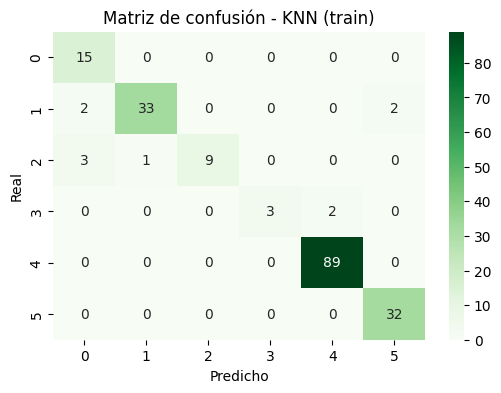


Accuracy (test): 0.917

Classification Report (test):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       0.89      0.89      0.89         9
           2       1.00      0.75      0.86         4
           4       0.00      0.00      0.00         1
           5       1.00      0.95      0.98        22
           6       0.89      1.00      0.94         8

    accuracy                           0.92        48
   macro avg       0.76      0.77      0.76        48
weighted avg       0.92      0.92      0.92        48



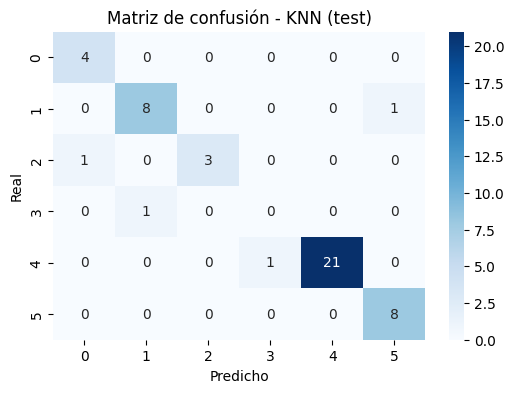

Entrenando modelo: Regresión Logística

Accuracy (train): 0.963

Classification Report (train):
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.94      0.92      0.93        37
           2       1.00      0.92      0.96        13
           4       1.00      0.80      0.89         5
           5       0.99      1.00      0.99        89
           6       0.94      1.00      0.97        32

    accuracy                           0.96       191
   macro avg       0.96      0.92      0.94       191
weighted avg       0.96      0.96      0.96       191



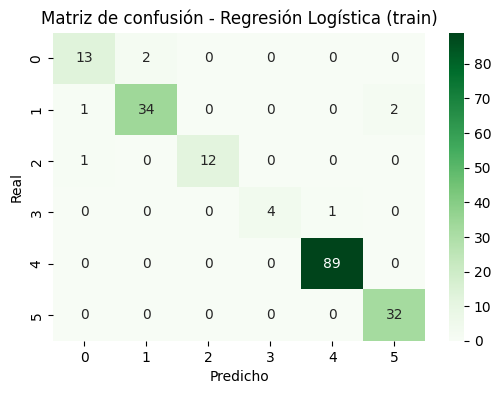


Accuracy (test): 0.875

Classification Report (test):
              precision    recall  f1-score   support

           0       0.57      1.00      0.73         4
           1       1.00      0.67      0.80         9
           2       1.00      0.75      0.86         4
           4       0.00      0.00      0.00         1
           5       0.95      0.95      0.95        22
           6       0.89      1.00      0.94         8

    accuracy                           0.88        48
   macro avg       0.74      0.73      0.71        48
weighted avg       0.90      0.88      0.88        48



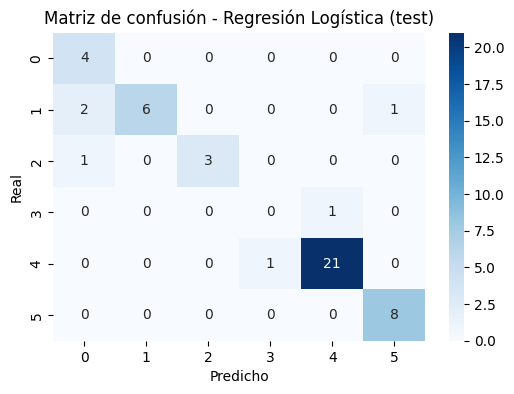

Entrenando modelo: Árbol de Decisión

Accuracy (train): 1.000

Classification Report (train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        13
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00        89
           6       1.00      1.00      1.00        32

    accuracy                           1.00       191
   macro avg       1.00      1.00      1.00       191
weighted avg       1.00      1.00      1.00       191



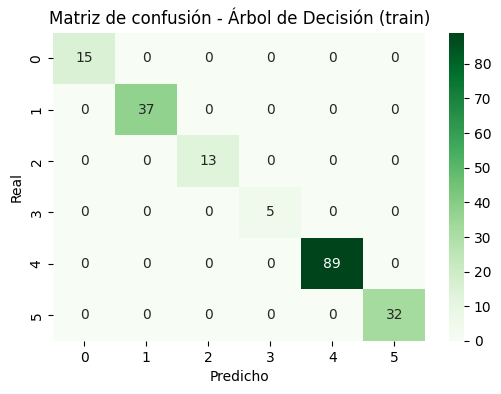


Accuracy (test): 0.812

Classification Report (test):
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.83      0.56      0.67         9
           2       0.50      0.75      0.60         4
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00        22
           6       0.75      0.75      0.75         8

    accuracy                           0.81        48
   macro avg       0.68      0.63      0.65        48
weighted avg       0.86      0.81      0.83        48



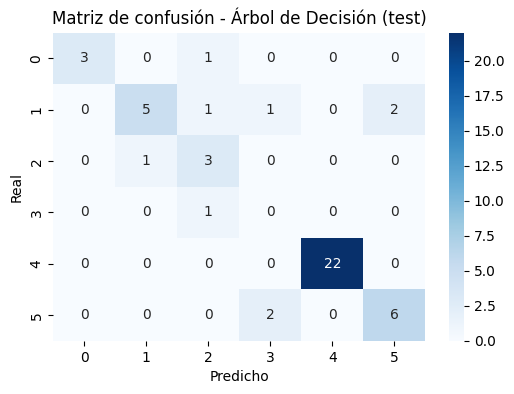

In [20]:
for nombre, modelo in modelos.items():
    print(f"Entrenando modelo: {nombre}")

    modelo.fit(X_train_scaled, y_train)

    y_train_pred = modelo.predict(X_train_scaled)
    acc_train = accuracy_score(y_train, y_train_pred)

    print(f"\nAccuracy (train): {acc_train:.3f}")
    print("\nClassification Report (train):")
    print(classification_report(y_train, y_train_pred, zero_division=0))

    cm_train = confusion_matrix(y_train, y_train_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens')
    plt.title(f"Matriz de confusión - {nombre} (train)")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

    y_test_pred = modelo.predict(X_test_scaled)
    acc_test = accuracy_score(y_test, y_test_pred)
    resultados_test[nombre] = acc_test

    print(f"\nAccuracy (test): {acc_test:.3f}")
    print("\nClassification Report (test):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    cm_test = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de confusión - {nombre} (test)")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()


### 2.3 - Comparación de los modelos

/var/folders/w5/r4237v9175jgsj0grkn8tkhr0000gn/T/ipykernel_8596/1149215720.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


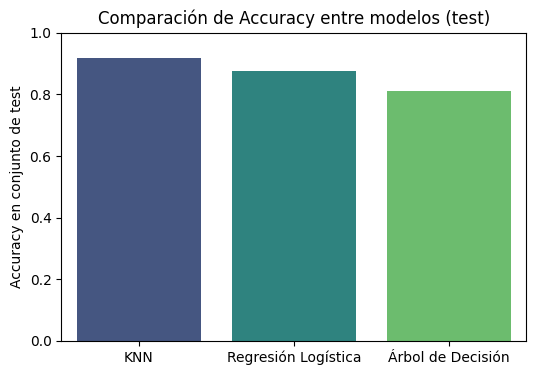


Resultados comparativos de Accuracy (test):
KNN                 : 0.917
Regresión Logística : 0.875
Árbol de Decisión   : 0.812


In [21]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=list(resultados_test.keys()),
    y=list(resultados_test.values()),
    palette='viridis'
)
plt.title("Comparación de Accuracy entre modelos (test)")
plt.ylabel("Accuracy en conjunto de test")
plt.ylim(0, 1)
plt.show()

print("\nResultados comparativos de Accuracy (test):")
for modelo, acc in resultados_test.items():
    print(f"{modelo:20s}: {acc:.3f}")

# PARTE C

### 3.1 - Ajuste de hiperparámetros

In [22]:
knn_modificado = KNeighborsClassifier(
    n_neighbors=9,          
    weights='distance',     
    metric='manhattan'      
)

logreg_modificado = LogisticRegression(
    max_iter=1000,
    C=0.5,                  
    penalty='l2',           
    solver='lbfgs',
    random_state=42
)

tree_modificado = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,            
    criterion='entropy',    
    min_samples_split=5     
)

modelos_modificados = {
    "KNN (modificado)": knn_modificado,
    "Regresión Logística (modificada)": logreg_modificado,
    "Árbol de Decisión (modificado)": tree_modificado
}

resultados_modificados = {}

### 3.2 - Entrenamiento y evaluación

Entrenando modelo: KNN (modificado)

Accuracy (train): 1.000

Classification Report (train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        13
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00        89
           6       1.00      1.00      1.00        32

    accuracy                           1.00       191
   macro avg       1.00      1.00      1.00       191
weighted avg       1.00      1.00      1.00       191



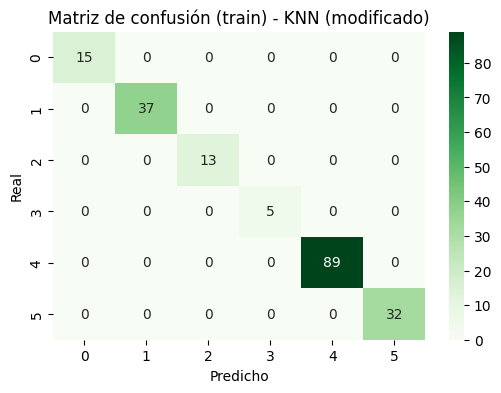


Accuracy (test): 0.896

Classification Report (test):
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       0.88      0.78      0.82         9
           2       1.00      0.75      0.86         4
           4       0.00      0.00      0.00         1
           5       1.00      0.95      0.98        22
           6       0.89      1.00      0.94         8

    accuracy                           0.90        48
   macro avg       0.74      0.75      0.73        48
weighted avg       0.91      0.90      0.90        48



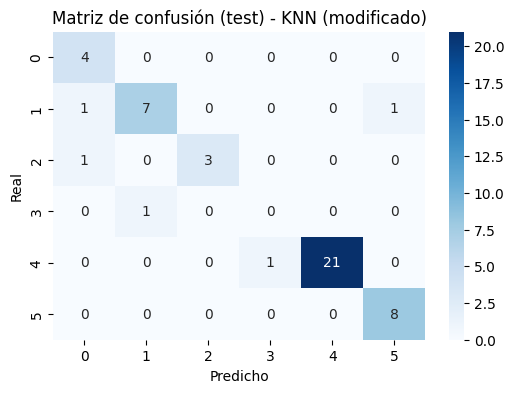

Entrenando modelo: Regresión Logística (modificada)

Accuracy (train): 0.948

Classification Report (train):
              precision    recall  f1-score   support

           0       0.83      0.67      0.74        15
           1       0.87      0.92      0.89        37
           2       1.00      0.92      0.96        13
           4       1.00      0.80      0.89         5
           5       0.99      1.00      0.99        89
           6       0.94      1.00      0.97        32

    accuracy                           0.95       191
   macro avg       0.94      0.88      0.91       191
weighted avg       0.95      0.95      0.95       191



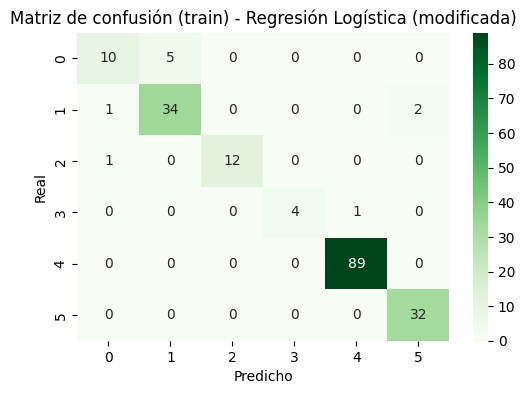


Accuracy (test): 0.875

Classification Report (test):
              precision    recall  f1-score   support

           0       0.57      1.00      0.73         4
           1       1.00      0.67      0.80         9
           2       1.00      0.75      0.86         4
           4       0.00      0.00      0.00         1
           5       0.95      0.95      0.95        22
           6       0.89      1.00      0.94         8

    accuracy                           0.88        48
   macro avg       0.74      0.73      0.71        48
weighted avg       0.90      0.88      0.88        48



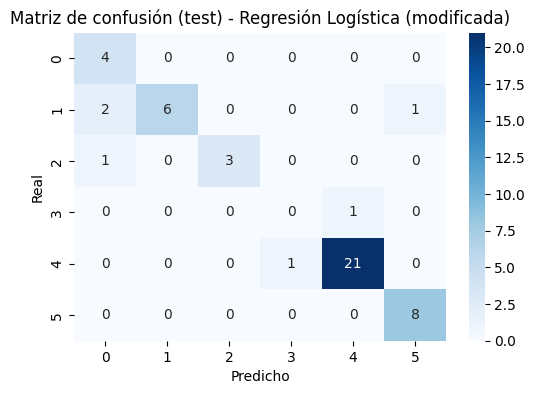

Entrenando modelo: Árbol de Decisión (modificado)

Accuracy (train): 0.979

Classification Report (train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.92      0.97      0.95        37
           2       1.00      0.77      0.87        13
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00        89
           6       0.97      1.00      0.98        32

    accuracy                           0.98       191
   macro avg       0.98      0.96      0.97       191
weighted avg       0.98      0.98      0.98       191



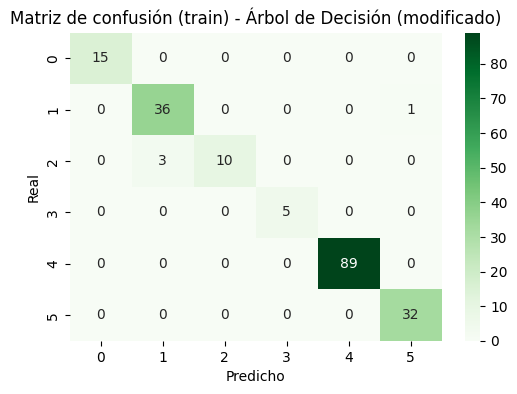


Accuracy (test): 0.833

Classification Report (test):
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.78      0.78      0.78         9
           2       0.50      0.25      0.33         4
           4       0.50      1.00      0.67         1
           5       1.00      1.00      1.00        22
           6       0.75      0.75      0.75         8

    accuracy                           0.83        48
   macro avg       0.69      0.75      0.70        48
weighted avg       0.83      0.83      0.83        48



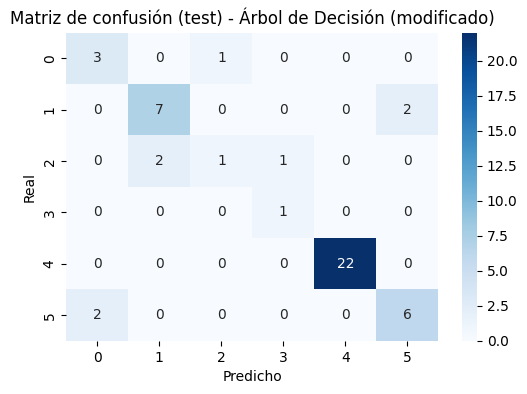

In [23]:
for nombre, modelo in modelos_modificados.items():

    print(f"Entrenando modelo: {nombre}")

    modelo.fit(X_train_scaled, y_train)

    y_train_pred = modelo.predict(X_train_scaled)
    acc_train = accuracy_score(y_train, y_train_pred)

    print(f"\nAccuracy (train): {acc_train:.3f}")
    print("\nClassification Report (train):")
    print(classification_report(y_train, y_train_pred, zero_division=0))

    cm_train = confusion_matrix(y_train, y_train_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens')
    plt.title(f"Matriz de confusión (train) - {nombre}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

    y_test_pred = modelo.predict(X_test_scaled)
    acc_test = accuracy_score(y_test, y_test_pred)
    resultados_modificados[nombre] = acc_test

    print(f"\nAccuracy (test): {acc_test:.3f}")
    print("\nClassification Report (test):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    cm_test = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de confusión (test) - {nombre}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

### 3.3 - Comparación con los modelos originales

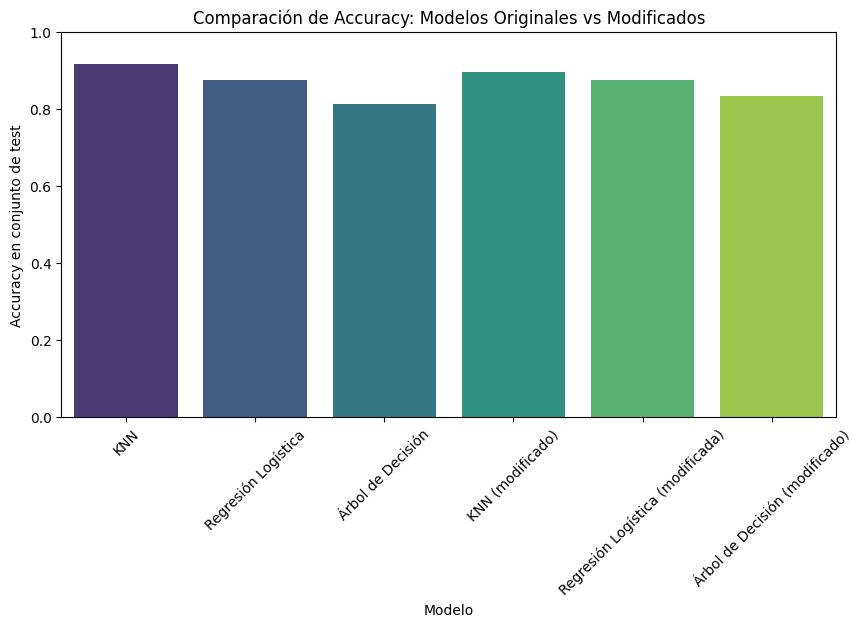


Resultados comparativos ordenados:


,Modelo,Accuracy
0,KNN,0.917
3,KNN (modificado),0.896
1,Regresión Logística,0.875
4,Regresión Logística (modificada),0.875
5,Árbol de Decisión (modificado),0.833
2,Árbol de Decisión,0.812


In [24]:
df_comparacion = pd.DataFrame({
    "Modelo": list(resultados_test.keys()) + list(resultados_modificados.keys()),
    "Accuracy": list(resultados_test.values()) + list(resultados_modificados.values())
})

plt.figure(figsize=(10,5))
sns.barplot(
    data=df_comparacion,
    x="Modelo", y="Accuracy", hue="Modelo",
    palette="viridis",
    legend=False
)
plt.title("Comparación de Accuracy: Modelos Originales vs Modificados")
plt.ylabel("Accuracy en conjunto de test")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

print("\nResultados comparativos ordenados:")
display(df_comparacion.sort_values("Accuracy", ascending=False))

# PARTE 4


Accuracy (train): 0.948

Reporte de clasificación (train):
              precision    recall  f1-score   support

           0       0.75      1.00      0.86        15
           1       0.97      0.89      0.93        37
           2       1.00      0.69      0.82        13
           4       1.00      0.60      0.75         5
           5       0.98      1.00      0.99        89
           6       0.94      1.00      0.97        32

    accuracy                           0.95       191
   macro avg       0.94      0.86      0.89       191
weighted avg       0.95      0.95      0.95       191


Accuracy (test): 0.917

Reporte de clasificación (test):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       0.89      0.89      0.89         9
           2       1.00      0.75      0.86         4
           4       0.00      0.00      0.00         1
           5       1.00      0.95      0.98        22
           6  

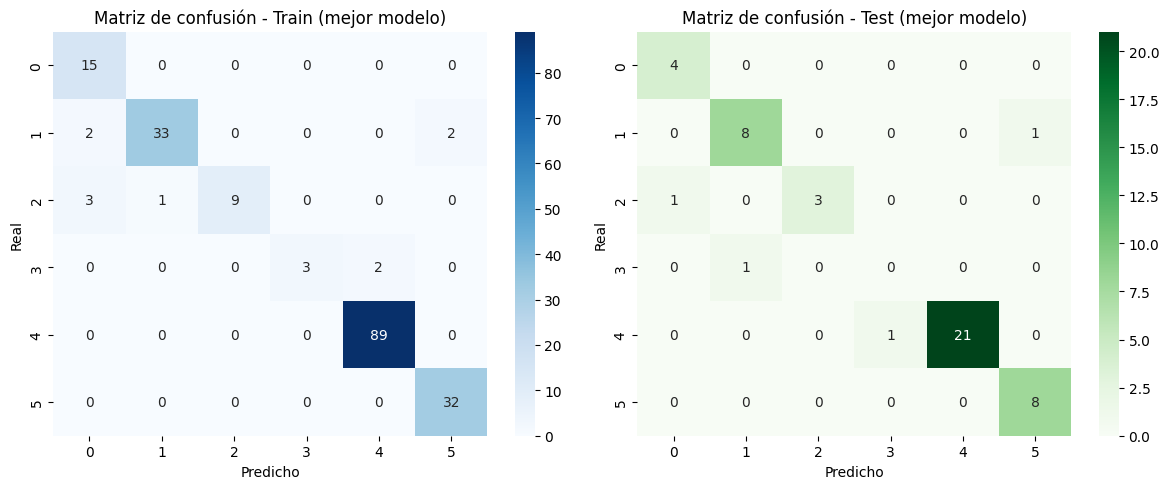


Comparación de Accuracy:
Train: 0.948
Test:  0.917


In [26]:
# Mejor modelo seleccionado: KNN original
mejor_modelo = KNeighborsClassifier(
    n_neighbors=5,    
    weights='uniform',
    metric='minkowski'
)

mejor_modelo.fit(X_train_scaled, y_train)

# Train
y_pred_train = mejor_modelo.predict(X_train_scaled)
acc_train = accuracy_score(y_train, y_pred_train)
print(f"\nAccuracy (train): {acc_train:.3f}")
print("\nReporte de clasificación (train):")
print(classification_report(y_train, y_pred_train, zero_division=0))

# Test
y_pred_test = mejor_modelo.predict(X_test_scaled)
acc_test = accuracy_score(y_test, y_pred_test)
print(f"\nAccuracy (test): {acc_test:.3f}")
print("\nReporte de clasificación (test):")
print(classification_report(y_test, y_pred_test, zero_division=0))

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    confusion_matrix(y_train, y_pred_train),
    annot=True, fmt='d', cmap='Blues', ax=axes[0]
)
axes[0].set_title("Matriz de confusión - Train (mejor modelo)")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

sns.heatmap(
    confusion_matrix(y_test, y_pred_test),
    annot=True, fmt='d', cmap='Greens', ax=axes[1]
)
axes[1].set_title("Matriz de confusión - Test (mejor modelo)")
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

print("\nComparación de Accuracy:")
print(f"Train: {acc_train:.3f}")
print(f"Test:  {acc_test:.3f}")
